# Análisis exploratorio — Rest-Mex 2025

Corpus de reseñas turísticas en español sobre Pueblos Mágicos de México
(desafío REST-MEX 2025). Antes de entrenar cualquier modelo, este notebook
responde tres preguntas:

1. ¿Cómo se distribuyen las tres variables objetivo (polaridad, tipo de lugar, pueblo)?
2. ¿Qué tan largos son los textos? (define el `max_length` del tokenizador)
3. ¿Qué problemas de calidad trae el corpus? (nulos, duplicados, artefactos de scraping)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Paleta (un matiz para magnitudes; rampa ordinal azul para polaridad)
BLUE = "#2a78d6"
RAMP5 = ["#86b6ef", "#5598e7", "#3987e5", "#256abf", "#1c5cab"]  # 1→5
SURFACE, INK, INK2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif", "figure.dpi": 110,
})

def style_bars(ax, horizontal=False):
    ax.grid(axis="y" if not horizontal else "x")
    ax.grid(False, axis="x" if not horizontal else "y")
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)

df = pd.read_csv("../data/Rest-Mex_2025_train.csv")
print(f"{len(df):,} reseñas × {df.shape[1]} columnas")
df.head(3)

208,051 reseñas × 6 columnas


,Title,Review,Polarity,Town,Region,Type
0,Mi Lugar Favorito!!!!,Excelente lugar para comer y pasar una buena n...,5.0,Sayulita,Nayarit,Restaurant
1,lugares interesantes para visitar,"andar mucho, así que un poco difícil para pers...",4.0,Tulum,QuintanaRoo,Attractive
2,No es el mismo Dreams,"Es nuestra cuarta visita a Dreams Tulum, elegi...",3.0,Tulum,QuintanaRoo,Hotel


## Calidad de los datos

In [2]:
resumen = pd.DataFrame({
    "nulos": df.isna().sum(),
    "únicos": df.nunique(),
    "dtype": df.dtypes.astype(str),
})
print(resumen)
print(f"\nDuplicados exactos (fila completa): {df.duplicated().sum()}")
print(f"Duplicados de Title+Review:          {df.duplicated(subset=['Title','Review']).sum()}")
print(f"\nReseñas que terminan en 'Más' (artefacto del scraping de TripAdvisor): "
      f"{df.Review.astype(str).str.endswith('Más').sum():,}")

          nulos  únicos    dtype
Title         2  142966      str
Review        0  207841      str
Polarity      0       5  float64
Town          0      40      str
Region        0      19      str
Type          0       3      str



Duplicados exactos (fila completa): 178


Duplicados de Title+Review:          180

Reseñas que terminan en 'Más' (artefacto del scraping de TripAdvisor): 37,902


Hallazgos: solo 2 títulos nulos, 178 filas duplicadas exactas (se eliminan),
`Polarity` viene como float (se castea a int). Miles de reseñas terminan en
`...Más` — el texto del botón "ver más" de TripAdvisor quedó pegado al final;
conviene limpiarlo porque no aporta señal.

## Polaridad: desbalanceo severo

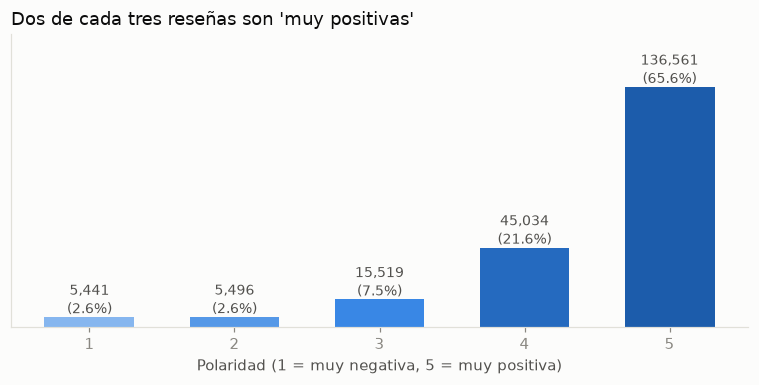

Razón de desbalanceo clase 5 vs clase 1: 25:1


In [3]:
pol = df.Polarity.astype(int).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar(pol.index.astype(str), pol.values, color=RAMP5, width=0.62)
for b, v in zip(bars, pol.values):
    ax.annotate(f"{v:,}\n({v/len(df):.1%})", (b.get_x() + b.get_width()/2, v),
                ha="center", va="bottom", fontsize=9, color=INK2, linespacing=1.3)
ax.set_ylim(0, pol.max() * 1.22)
ax.set_yticks([])
ax.set_xlabel("Polaridad (1 = muy negativa, 5 = muy positiva)")
ax.set_title("Dos de cada tres reseñas son 'muy positivas'", loc="left", fontsize=12, color=INK)
style_bars(ax)
ax.grid(False)
plt.tight_layout(); plt.savefig("figures/polaridad.png", bbox_inches="tight"); plt.show()
print(f"Razón de desbalanceo clase 5 vs clase 1: {pol[5]/pol[1]:.0f}:1")

La clase 5 tiene **25 veces** más instancias que la clase 1. Con *accuracy* a
secas, un modelo que siempre diga "5" acierta 66% — por eso el reto evalúa con
métricas por clase. Implicación: pesos de clase en la pérdida o *sampling*
balanceado (opcional según el enunciado, pero al menos hay que medir F1 macro).

## Tipo de lugar: manejable

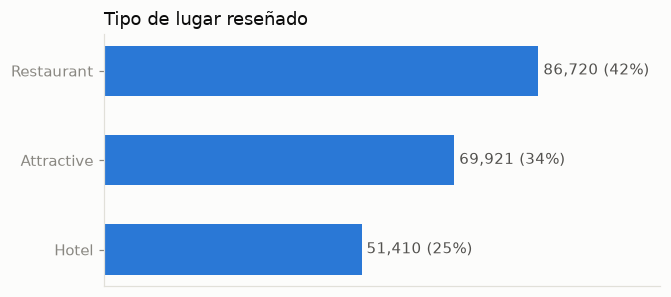

In [4]:
tipo = df.Type.value_counts()
fig, ax = plt.subplots(figsize=(6.2, 2.8))
bars = ax.barh(tipo.index[::-1], tipo.values[::-1], color=BLUE, height=0.56)
for b, v in zip(bars, tipo.values[::-1]):
    ax.annotate(f" {v:,} ({v/len(df):.0%})", (v, b.get_y() + b.get_height()/2),
                va="center", fontsize=9.5, color=INK2)
ax.set_xlim(0, tipo.max() * 1.28)
ax.set_xticks([])
ax.set_title("Tipo de lugar reseñado", loc="left", fontsize=12, color=INK)
style_bars(ax, horizontal=True)
ax.grid(False)
plt.tight_layout(); plt.savefig("figures/tipo.png", bbox_inches="tight"); plt.show()

## Pueblos Mágicos: cola larga de 40 clases

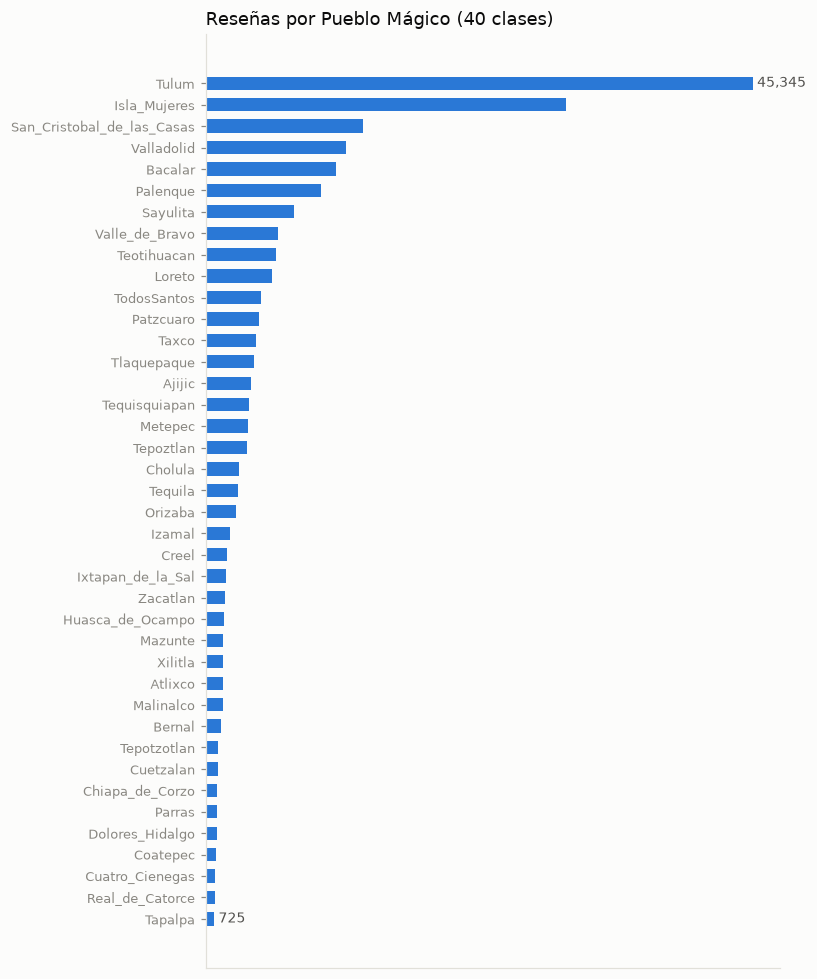

Top-2 (Tulum + Isla_Mujeres) concentran 36% del corpus; razón máx/mín: 63:1


In [5]:
town = df.Town.value_counts()
fig, ax = plt.subplots(figsize=(7.5, 9))
bars = ax.barh(town.index[::-1], town.values[::-1], color=BLUE, height=0.62)
ax.annotate(f" {town.max():,}", (town.max(), bars[-1].get_y() + bars[-1].get_height()/2),
            va="center", fontsize=9, color=INK2)
ax.annotate(f" {town.min():,}", (town.min(), bars[0].get_y() + bars[0].get_height()/2),
            va="center", fontsize=9, color=INK2)
ax.set_xticks([])
ax.tick_params(axis="y", labelsize=8.5)
ax.set_title("Reseñas por Pueblo Mágico (40 clases)", loc="left", fontsize=12, color=INK)
style_bars(ax, horizontal=True)
ax.grid(False)
plt.tight_layout(); plt.savefig("figures/pueblos.png", bbox_inches="tight"); plt.show()
print(f"Top-2 (Tulum + Isla_Mujeres) concentran {(town.iloc[0]+town.iloc[1])/len(df):.0%} del corpus; "
      f"razón máx/mín: {town.max()/town.min():.0f}:1")

Tulum solo concentra el 22% del corpus y los últimos ~10 pueblos tienen menos
de 1,000 reseñas cada uno (Tapalpa: 725). La tarea de pueblo es la más difícil
de las tres: 40 clases, desbalanceo 63:1, y la señal depende de menciones
explícitas del lugar en el texto.

## Longitud de los textos

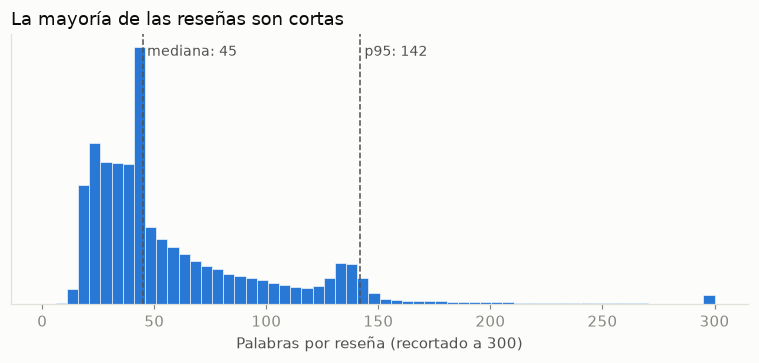

count    208051.0
mean         61.5
std          50.5
min           1.0
50%          45.0
90%         131.0
95%         142.0
99%         241.0
max        1479.0
Name: Review, dtype: float64

Mediana de palabras por polaridad:
Polarity
1    54.0
2    57.0
3    49.0
4    45.0
5    44.0
Name: Review, dtype: float64


In [6]:
words = df.Review.astype(str).str.split().str.len()
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(words.clip(upper=300), bins=60, color=BLUE, edgecolor=SURFACE, linewidth=0.4)
for q, lbl in [(words.median(), "mediana"), (words.quantile(0.95), "p95")]:
    ax.axvline(q, color=INK2, linewidth=1, linestyle="--")
    ax.annotate(f" {lbl}: {q:.0f}", (q, ax.get_ylim()[1]*0.92), fontsize=9, color=INK2)
ax.set_xlabel("Palabras por reseña (recortado a 300)")
ax.set_yticks([])
ax.set_title("La mayoría de las reseñas son cortas", loc="left", fontsize=12, color=INK)
style_bars(ax)
plt.tight_layout(); plt.savefig("figures/longitud.png", bbox_inches="tight"); plt.show()
print(words.describe([.5, .9, .95, .99]).round(1))
print("\nMediana de palabras por polaridad:")
print(words.groupby(df.Polarity.astype(int)).median())

Mediana de 45 palabras, p95 de 142. Con subpalabras (~1.3 tokens/palabra),
**`max_length=256` cubre >99% de las reseñas** sin truncar señal; 128 ya cubre
~90% y entrena al doble de velocidad. Dato curioso: las reseñas negativas son
más largas (mediana 54–57 palabras) que las positivas (44) — la gente detalla
más cuando se queja.

## Conjunto de prueba y versión reducida

In [7]:
test = pd.read_excel("../data/Rest-Mex_2025_test.xlsx")
print(f"Test: {len(test):,} filas, columnas {list(test.columns)} (sin etiquetas)")
meia_tr = pd.read_excel("../data/Datos-MeIA-Reto-01/MeIA_2025_train.xlsx")
meia_te = pd.read_excel("../data/Datos-MeIA-Reto-01/MeIA_2025_test_wo_labels.xlsx")
print(f"MeIA reducido: train {meia_tr.shape}, test {meia_te.shape}")
print(f"Polaridad en MeIA train (casi balanceada): "
      f"{meia_tr.Polarity.astype(int).value_counts().sort_index().to_dict()}")

Test: 89,166 filas, columnas ['ID', 'Title', 'Review'] (sin etiquetas)


MeIA reducido: train (5000, 5), test (2500, 5)
Polaridad en MeIA train (casi balanceada): {1: 800, 2: 900, 3: 1000, 4: 1100, 5: 1200}


Nota: la versión reducida (MeIA) está **casi balanceada** (800–1,200 por clase)
y su test trae Town/Region/Type como *features* — solo se predice polaridad.
Sirve para validar el flujo de fine-tuning rápido, pero su distribución no
representa la del corpus completo: no extrapolar hiperparámetros de sampling.

## Conclusiones para el modelado

| Decisión | Valor | Por qué |
|---|---|---|
| Limpieza | quitar sufijo `Más`, 178 duplicados, castear Polarity a int | artefactos sin señal |
| Entrada del modelo | `Title + ". " + Review` | el título condensa el sentimiento |
| `max_length` | 256 (128 para iterar) | p95 = 142 palabras |
| Modelo base | BERT en español (BETO) o multilingüe | corpus 100% en español |
| Desbalanceo | pesos de clase en polaridad y pueblo; medir F1 macro | 25:1 y 63:1 |
| Región | *feature* auxiliar para la cabeza de pueblo | 19 regiones → restringe los 40 pueblos |
| Validación | split estratificado por (Polarity, Town) | preservar clases raras |